In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 22,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 12,             # X tick label size (8-12)
    "ytick.labelsize": 12,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
})


from pathlib import Path
# print(SCRIPT_DIR)

# --- File path handling
# SCRIPT_DIR = Path(__file__).resolve().parent  # .py
SCRIPT_DIR = Path.cwd()  # .ipynb
FIGURES_DIR = SCRIPT_DIR / "figures/presentation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)   # creates ./figures/ if needed

# --- Base path
# base_path = Path(r"J:\new_target")  # IDUN
base_path = Path(r"C:\Users\Silje\OneDrive\Dokumenter\mscneuroscience20242026\nevr3901\simulations_folder\may_simulations")  # home
# base_path = SCRIPT_DIR  # original
base_path.mkdir(parents=True, exist_ok=True)




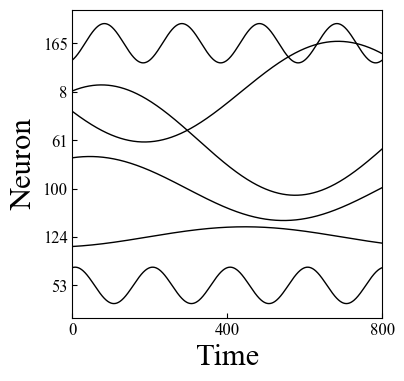

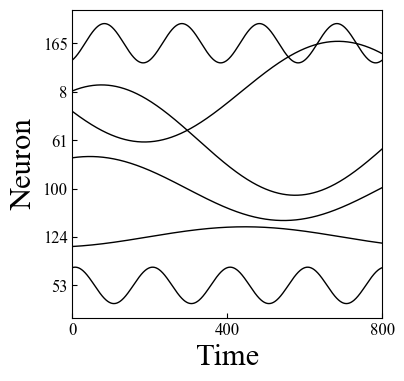

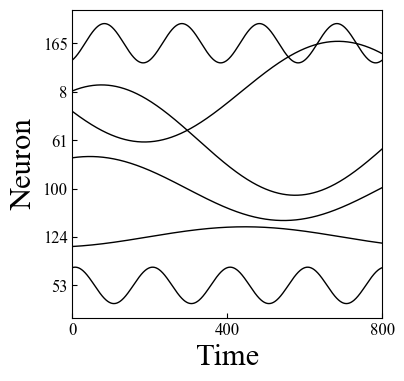

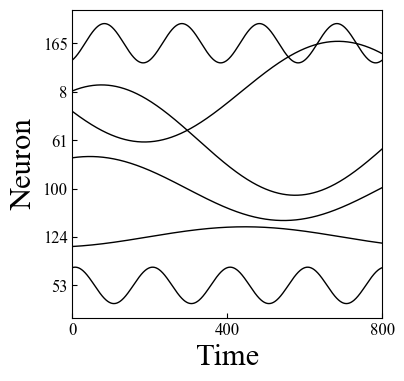

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

iloop = 14 #testing loop

# Simulation identifiers
idx = 9
pqif = 0.5

simulations = [i for i in range(1, 5)]

for idx in simulations:

    # Load simulation data
    target = pd.read_csv(Path(base_path / 
        f'simulation_{idx}/simulation_{idx}_targets_{pqif}.csv')
    ).values

    inputs = pd.read_csv(Path(base_path /
        f'simulation_{idx}/simulation_{idx}_inputs/'
        f'simulation_{idx}_inputs_pqif_{pqif}_iloop_{iloop}_seed_0.csv'),
        header=None
    ).values

    outputs = pd.read_csv(Path(base_path / 
        f'simulation_{idx}/simulation_{idx}_outputs/'
        f'simulation_{idx}_outputs_pqif_{pqif}_iloop_{iloop}_seed_0.csv'),
        header=None
    ).values

    pretrain_inputs = pd.read_csv(Path(base_path / 
        f'simulation_{idx}/simulation_{idx}_inputs/'
        f'simulation_{idx}_inputs_pqif_{pqif}_iloop_0_seed_0.csv'),
        header=None
    ).values

    # Discard initial transient (200 ms)
    inputs_rest = np.nan_to_num(inputs[200:, :])
    target_rest = np.nan_to_num(target[200:, :])
    pretrain_rest = np.nan_to_num(pretrain_inputs[200:, :])
    outputs_rest = np.nan_to_num(outputs[200:, :])

    # Randomly choose neurons for oscillation traces
    rng = np.random.default_rng(seed=0)
    n_neurons_to_plot = 6
    chosen_neurons = rng.choice(inputs_rest.shape[1], size=n_neurons_to_plot, replace=False)

    # Choose what to plot: inputs_rest, target_rest, outputs_rest, etc.
    osc_data = target_rest[:, chosen_neurons]   # shape: time x selected neurons

    # Time window
    t0, t1 = 0, 800
    osc_data = osc_data[t0:t1, :]

    # Normalize each neuron separately, because each may have its own scale
    # osc_norm = (osc_data - osc_data.mean(axis=0)) / osc_data.std(axis=0)

    # Vertical offsets
    offsets = np.arange(n_neurons_to_plot) * 3


    fig, ax = plt.subplots(figsize=(4, 4))

    time = np.arange(t0, t1)

    for i, neuron_idx in enumerate(chosen_neurons):
        ax.plot(
            time,
            # osc_norm[:, i] + offsets[i],
            osc_data[:, i] + offsets[i],
            color='black',
            linewidth=1
        )

    ax.set_xlabel('Time')
    ax.set_ylabel('Neuron')

    ax.set_yticks(offsets)
    ax.set_yticklabels(chosen_neurons)

    time_xax = np.linspace(0, 800, 3).round().astype(int)
    ax.set_xticks(time_xax)
    
    ax.set_xlim(t0, t1)

    fig_path = FIGURES_DIR / f"oscillations_sim_{idx}.svg"
    plt.savefig(fig_path, dpi=300)
    plt.show()



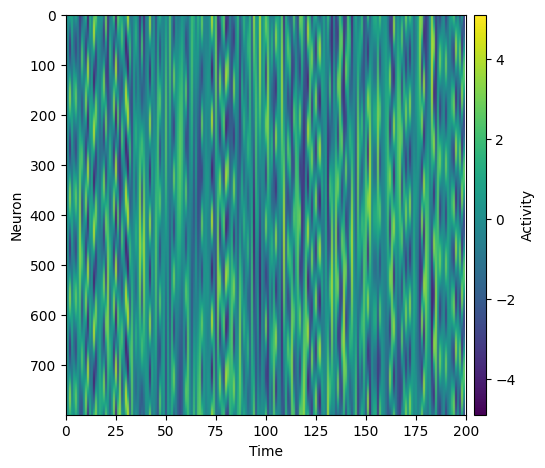

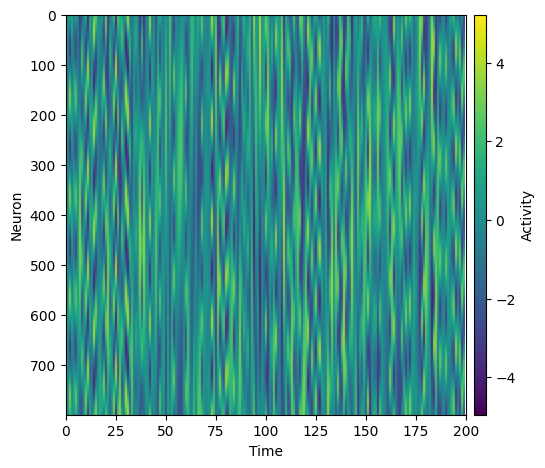

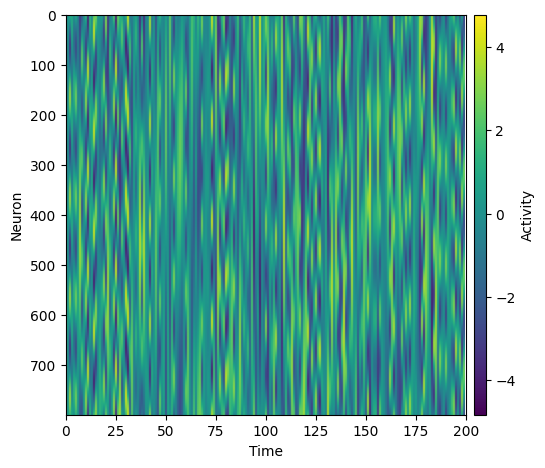

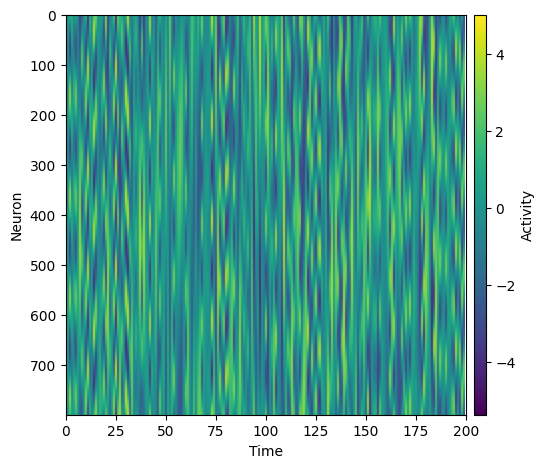

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

iloop = 14 #testing loop

# Simulation identifiers (change it according to your codes)
idx = 1
pqif = 0

simulations = [i for i in range(1, 5)]

for idx in simulations:

    # Load simulation data
    target = pd.read_csv(
        f'simulation_{idx}/simulation_{idx}_targets_{pqif}.csv'
    ).values

    inputs = pd.read_csv(
        f'simulation_{idx}/simulation_{idx}_inputs/'
        f'simulation_{idx}_inputs_pqif_{pqif}_iloop_{iloop}_seed_0.csv',
        header=None
    ).values

    outputs = pd.read_csv(
        f'simulation_{idx}/simulation_{idx}_outputs/'
        f'simulation_{idx}_outputs_pqif_{pqif}_iloop_{iloop}_seed_0.csv',
        header=None
    ).values

    pretrain_inputs = pd.read_csv(
        f'simulation_{idx}/simulation_{idx}_inputs/'
        f'simulation_{idx}_inputs_pqif_{pqif}_iloop_0_seed_0.csv',
        header=None
    ).values

    # Discard initial transient (200 ms)
    inputs_rest = np.nan_to_num(inputs[200:, :])
    target_rest = np.nan_to_num(target[200:, :])
    pretrain_rest = np.nan_to_num(pretrain_inputs[200:, :])
    outputs_rest = np.nan_to_num(outputs[200:, :])

    # Shared color scale
    vmin = min(pretrain_rest.min(), inputs_rest.min(), target_rest.min())
    vmax = max(pretrain_rest.max(), inputs_rest.max(), target_rest.max())

    # Figure setup
    # square_size = 1.2
    square_size = 4
    fig = plt.figure(figsize=(square_size, square_size))

    # Manually place the main axes
    ax = fig.add_axes([
        0.15,
        0.12,
        square_size / fig.get_figwidth(),
        square_size / fig.get_figheight()
    ])

        # Plot
    im = ax.imshow(
        target_rest,
        cmap='viridis',
        # cmap='inferno',
        # cmap='cividis',
        aspect='auto',
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlabel('Time')
    ax.set_ylabel('Neuron')
    # ax.set_ylim(0, 150)
    # ax.set_ylim(150, 0)
    ax.set_xlim(0,200)

    # Colorbar aligned with the main axes
    pos = ax.get_position()
    cbar_ax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.03, pos.height])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
    cbar.set_label('Activity')

    plt.show()